In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import empymod 
from scipy.constants import mu_0

In [4]:
nlay=9
thk = np.logspace(-0.3,0.35,8)
depth = np.hstack(([0],-np.cumsum(thk)))

# Forward function for the DUALEM instrument
def FDEM(sigmas, thicks=thk, coil_orient=np.array(['H', 'P', 'V']), height=0.15):

    """
    Forward function for the DUALEM instrument

    Inputs:
    sigmas : Electrical conductivities array in S/m
    thicks : Thicknesses array in m
    coil_orient :  coil orientations
    height : height of the instrument
    
    Returns array [HOP, HIP, VOP, VIP, POP, PIP] 

    """

    Freq = 9000
    coil_spacing = [2, 4, 8]
    coil_spacing_p = [2.1, 4.1, 8.2]
    
    res_air = 1e6 # air resistivity
    
    sigmas = np.array(sigmas)
    res = np.hstack(([res_air], 1/sigmas))    
    depth = np.hstack(([0],-np.cumsum(thicks)))
        
    # Define source and receivers geometry
    
    source = [0, 0, -height]
    receivers = [coil_spacing, np.zeros_like(coil_spacing), -height]
    receivers_p = [coil_spacing_p, np.zeros_like(coil_spacing_p), -height]
       
    # Empty array to store store responses
    OUT = []
    
    # Calculate for horizontal coil orientation
    if any(coil_orient == 'H'):
        # Secondary magnetic field
        H_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        H_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                              ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag  # Out of Phase
        ip = (H_Hs/H_Hp).real  # In Phase
        OUT.append([op, ip])

    # Calculate for vertical coil orientation
    if any(coil_orient == 'V'):
        # Secondary magnetic field
        V_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 55, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        V_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq, ab = 55, 
                              verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag  # Out of Phase
        ip = (V_Hs/V_Hp).real  # In Phase
        OUT.append([op, ip])

    # Calculate for perpendicular coil orientation
    if any(coil_orient == 'P'):
        P_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 46, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime= Freq,
                              ab = 66, verb = 0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag  # Out of Phase
        ip = (P_Hs/P_Hp).real  # In Phase

        OUT.append([op, ip])

    # Returns array [HOP, HIP, VOP, VIP, POP, PIP] 
    return np.array(OUT).ravel()

class myFwd(pg.Modelling):
    def __init__(self, depth):
        """Initialize the model."""
        self.dep = depth
        self.mesh1d = pg.meshtools.createMesh1D(len(self.dep))
        super().__init__()
        self.setMesh(self.mesh1d)
    
    def response(self, model):
        """Forward response."""
        A = FDEM(model)
        Avec = A.ravel()
        return Avec
        
    def createStartModel(self):
        return pg.Vector(len(self.dep)) * 100

In [48]:
model_MC = np.load('models_pred_9Lay_MC.npy')
model_MR = np.load('models_pred_9Lay_MC_1.npy')

data_MC = np.load('data_pred_9Lay_MC.npy')
data_MR = np.load('data_pred_9Lay_MC_1.npy')

In [49]:
# Setting forward operator 

fop = myFwd(depth)

#transThk = pg.trans.TransLogLU(0.1,5)
#transSig = pg.trans.TransLogLU(10/1000,2000/1000)

#fop.region(0).setTransModel(transThk)
#fop.region(1).setTransModel(transSig)

In [52]:
# Perform inversion in each position

npos = len(model_MR)
model_est_MR = []
response = []

for pos in range(npos):
    data = data_MR[pos]
    startModel = model_MR[pos]
    # error = np.abs(data) * 0.01 + 0.00001
    relativeError = np.ones_like(data) * 0.01
    data *= (np.random.randn(len(data)) * relativeError + 1.0)

    inv = pg.Inversion()
    inv.setForwardOperator(fop)
    transModel = pg.trans.TransLog(1) # > 1 Ohmm
    inv.transModel = transModel

    model_est_MR.append( inv.run(data, relativeError, startModel=startModel, verbose=False))
    response.append( inv.response)

    

In [53]:
model_MR_th = []
model_est_MR_th = []

for m in model_MR:
    model_MR_th.append(np.hstack((thk, m)))

for m in model_est_MR:
    model_est_MR_th.append(np.hstack((thk, m)))

<Axes: >

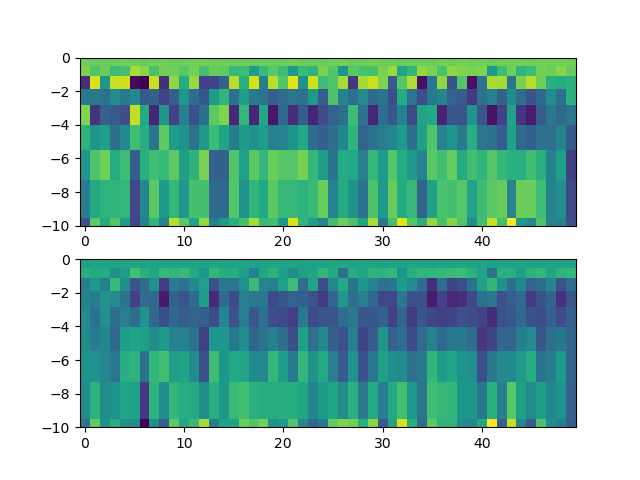

In [54]:
from pygimli.viewer.mpl import showStitchedModels

fig, ax = plt.subplots(2)

inputs = {'colorBar':False, 
         'zMax': 10}
showStitchedModels(model_MR_th, ax=ax[0], **inputs)
showStitchedModels(model_est_MR_th, ax=ax[1], **inputs)



In [52]:
np.save('model_est_9Lay_MC_1', model_est_MR) 

In [55]:
np.save('data_est_9Lay_MR_1', np.array(response))